## 3.2 线性回归的从零开始实现

In [2]:
import random
import torch
from d2l import torch as d2l

In [3]:
# generate dataset
def synthetic_data(w, b, num_examples):
    """生成线性回归数据集：y = Xw + b + 噪声
    参数:
      w (torch.Tensor): 权重向量，形状为 (d,) 或 (d, 1)
      b (float 或 torch.Tensor): 偏置
      num_examples (int): 生成的样本数量
    期望返回:
      X (torch.Tensor): 形状 (num_examples, d) 的特征矩阵
      y (torch.Tensor): 形状 (num_examples,) 的标签向量
    """
    # normal 函数从正态分布中采样张量：均值=0，标准差=1，形状=(样本数, 特征数)
    X = torch.normal(0, 1, (num_examples, len(w)))

    # 线性组合：矩阵乘法 X @ w + b，得到无噪声标签
    y = torch.matmul(X, w) + b

    # 加入高斯噪声：均值=0，标准差=0.01，形状与 y 相同
    y += torch.normal(0, 0.01, y.shape)

    # 调整 y 形状为 (num_examples, 1) 
    return X, y.reshape((-1, 1))

In [4]:
true_w = torch.tensor([2, -3.4])  # 真实权重
true_b = 4.2                     # 真实偏置
features, labels = synthetic_data(true_w, true_b, 1000)  # 生成1000个样本
features, labels

(tensor([[-1.2026,  0.6149],
         [-0.1834, -1.0792],
         [ 1.5210,  0.9577],
         ...,
         [ 0.9236, -0.9967],
         [-1.5328, -0.2085],
         [ 1.1402, -0.0551]]),
 tensor([[-2.9869e-01],
         [ 7.4967e+00],
         [ 3.9896e+00],
         [ 2.9361e+00],
         [ 5.6940e+00],
         [-3.4115e+00],
         [ 7.8914e+00],
         [ 8.1765e+00],
         [-1.9672e-01],
         [ 7.0455e+00],
         [ 2.3706e+00],
         [ 5.4099e+00],
         [ 3.8819e+00],
         [ 8.4290e+00],
         [ 3.1101e+00],
         [ 5.6963e+00],
         [ 7.4441e-01],
         [ 4.6609e+00],
         [ 8.9902e+00],
         [ 4.5465e+00],
         [-1.2584e+00],
         [-1.7556e+00],
         [ 4.0423e-01],
         [-2.9594e+00],
         [ 5.4564e+00],
         [ 1.0668e+00],
         [-1.2221e+00],
         [ 5.9496e+00],
         [ 4.3248e+00],
         [ 1.8936e+00],
         [ 9.1628e-01],
         [ 2.4554e+00],
         [ 2.0308e+00],
         [ 7.7670e

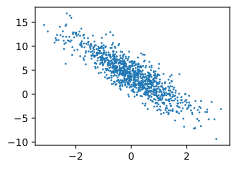

In [5]:
d2l.set_figsize()
d2l.plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1);  # 绘制散点图，观察特征与标签的关系

In [6]:
def data_iter(batch_size, features, labels):
    """生成批量数据迭代器
    参数:
      batch_size (int): 批量大小
      features (torch.Tensor): 特征矩阵
      labels (torch.Tensor): 标签向量
    期望返回:
      yield 每个批量的特征和标签
    """
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)  # 随机打乱索引顺序

    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)]
        )
        yield features[batch_indices], labels[batch_indices]

In [8]:
batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[-0.0418, -0.4124],
        [ 1.6369, -0.0891],
        [-0.0268, -1.0086],
        [-0.3731, -1.3430],
        [-0.0507,  0.8990],
        [ 1.2235,  0.1604],
        [ 0.9034,  1.1121],
        [-2.3317, -0.1054],
        [-1.4215,  1.2497],
        [-0.9209,  1.0293]]) 
 tensor([[ 5.5113],
        [ 7.7716],
        [ 7.5788],
        [ 8.0203],
        [ 1.0395],
        [ 6.0938],
        [ 2.2468],
        [-0.0955],
        [-2.8893],
        [-1.1261]])


In [16]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [10]:
def linreg(X, w, b):
    """线性回归模型
    参数:
      X (torch.Tensor): 特征矩阵
      w (torch.Tensor): 权重向量
      b (torch.Tensor): 偏置
    期望返回:
      torch.Tensor: 预测值
    """
    return torch.matmul(X, w) + b

In [11]:
def squared_loss(y_hat, y):
    """均方损失函数
    参数:
      y_hat (torch.Tensor): 预测值
      y (torch.Tensor): 真实标签
    期望返回:
      torch.Tensor: 每个样本的损失值
    """
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [12]:
def sgd(params, lr, batch_size):
    """小批量随机梯度下降
    参数:
      params (list of torch.Tensor): 模型参数
      lr (float): 学习率
      batch_size (int): 批量大小
    """
    with torch.no_grad():  # 禁用梯度计算
        for param in params:
            param -= lr * param.grad / batch_size  # 更新参数
            param.grad.zero_()  # 清零梯度

In [17]:
lr = 0.001  # 学习率
num_epochs = 100  # 迭代周期
net = linreg  # 线性回归模型
loss = squared_loss  # 均方损失函数

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # 计算损失
        l.sum().backward()  # 反向传播计算梯度
        sgd([w, b], lr, batch_size)  # 更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 13.133636
epoch 2, loss 10.824420
epoch 3, loss 8.922809
epoch 4, loss 7.356582
epoch 5, loss 6.066318
epoch 6, loss 5.003205
epoch 7, loss 4.127088
epoch 8, loss 3.404974
epoch 9, loss 2.809659
epoch 10, loss 2.318813
epoch 11, loss 1.914023
epoch 12, loss 1.580144
epoch 13, loss 1.304719
epoch 14, loss 1.077467
epoch 15, loss 0.889936
epoch 16, loss 0.735154
epoch 17, loss 0.607382
epoch 18, loss 0.501890
epoch 19, loss 0.414784
epoch 20, loss 0.342845
epoch 21, loss 0.283425
epoch 22, loss 0.234334
epoch 23, loss 0.193776
epoch 24, loss 0.160259
epoch 25, loss 0.132559
epoch 26, loss 0.109662
epoch 27, loss 0.090732
epoch 28, loss 0.075083
epoch 29, loss 0.062141
epoch 30, loss 0.051437
epoch 31, loss 0.042583
epoch 32, loss 0.035259
epoch 33, loss 0.029199
epoch 34, loss 0.024185
epoch 35, loss 0.020036
epoch 36, loss 0.016602
epoch 37, loss 0.013759
epoch 38, loss 0.011406
epoch 39, loss 0.009458
epoch 40, loss 0.007845
epoch 41, loss 0.006509
epoch 42, loss 0.005402